Example notebook of applying the `genalg` module to solve a random traveling salesman problem.

In [17]:
import numpy as np
import numpy.typing as npt
from algorithms.genalg import GeneticAlgorithm, selection, crossover, mutation, disaster
from matplotlib import pyplot as plt
import tqdm.notebook as tqdm

# Functions

In [18]:
def initialize_locations(num_locations: int) -> npt.NDArray[np.float64]:
    return np.random.uniform(0, 1, (num_locations, 2))


def initialize_ga(
        tournament_k: int, num_elites: int) -> GeneticAlgorithm:
    ga = GeneticAlgorithm(
        selection=selection.Tournament(k=tournament_k),
        crossover=crossover.PartiallyMapped(),
        mutations=[mutation.RSM(0.05)],
        num_elites=num_elites)
    return ga


def initialize_population(num_locations: int, pop_size: int) -> npt.NDArray[np.int_]:
    individuals = []
    for i in range(pop_size):
        ind = np.arange(num_locations)
        np.random.shuffle(ind)
        individuals.append(ind)
    population = np.stack(individuals)
    return population


def evaluate_route(locations: npt.NDArray[np.float64], route: npt.NDArray[np.int_]) -> float:
    i_nodes = route
    j_nodes = np.append(route[1:], route[0])

    distance = 0
    for (i, j) in zip(i_nodes, j_nodes):
        xi, yi = locations[i]
        xj, yj = locations[j]
        distance += ((xi-xj)**2 + (yi-yj)**2)**0.5
    return distance


def run_ga(
        ga: GeneticAlgorithm, locations: npt.NDArray[np.float64], 
        population: npt.NDArray[np.int_], num_iterations: int) -> tuple[npt.NDArray]:
    log_fitness = np.zeros((num_iterations, len(population)))
    log_routes = np.zeros((num_iterations, len(population), locations.shape[0]), dtype=int)

    for i in tqdm.tnrange(num_iterations):
        fitness = np.array([
            evaluate_route(locations, individual) for individual in population])
        log_fitness[i] = fitness
        log_routes[i] = population
        population = ga.evolve_population(population, -fitness).astype(int)
    
    return log_fitness, log_routes


def plot_route(ax, locations, route=None):
    if route is not None:
        ax.plot(
            *locations[np.append(route, route[0])].T,
            color='darkblue',
            zorder=0,
            alpha=0.3, 
            linewidth=1)
    ax.scatter(*locations.T, color='black', s=20, alpha=0.5)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)


def plot_evolution(ax, log_fitness):
    ax.plot(log_fitness.min(axis=1), label="best individual", linewidth=1)
    ax.plot(log_fitness.mean(axis=1), label="avg individual", linewidth=1)
    ax.legend()

# TSP

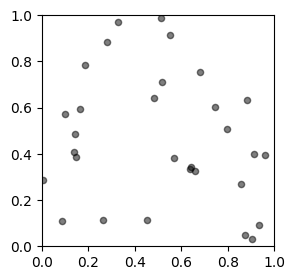

In [19]:
# Initialize problem and GA
locations = initialize_locations(
    num_locations=30)
fig, ax = plt.subplots(figsize=(3,3))
plot_route(ax, locations)
plt.show()

  0%|          | 0/400 [00:00<?, ?it/s]

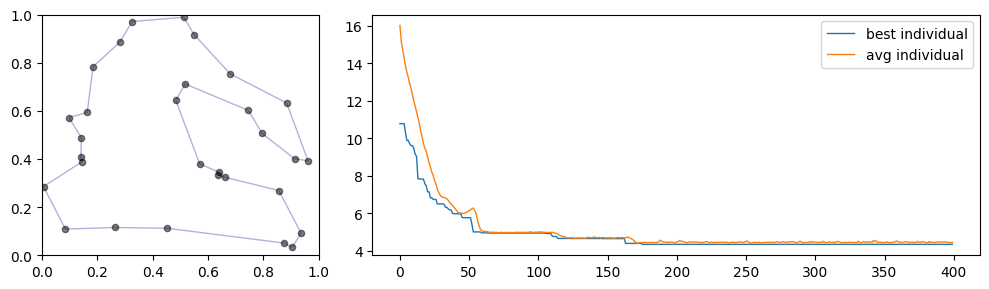

In [20]:
# Initialize population and GA
population = initialize_population(
    num_locations=locations.shape[0],
    pop_size=400)
ga = initialize_ga(
    tournament_k=3,
    num_elites=1)

# Run GA
log_fitness, log_routes = run_ga(ga, locations, population, num_iterations=400)


# Plot result
best_idx = np.unravel_index(log_fitness.argmin(), log_fitness.shape)
plt.figure(figsize=(10,3))
ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=1)
ax2 = plt.subplot2grid((1, 3), (0, 1), colspan=2)
plot_route(ax1, locations, log_routes[best_idx])
plot_evolution(ax2, log_fitness)
plt.tight_layout()
plt.show()